In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")

print("Path to dataset files:", path)

100%|██████████| 2.58G/2.58G [00:28<00:00, 96.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
print(path)

/root/.cache/kagglehub/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/versions/1


In [ ]:
import os

drive_path = "/content/drive/MyDrive/DDDD"
os.makedirs(drive_path, exist_ok=True)

print("Folder ready.")

Folder ready.


In [ ]:
import shutil

shutil.copytree(path, drive_path, dirs_exist_ok=True)

print("Dataset copied successfully!")

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3730126171.py", line 3, in <cell line: 0>
    shutil.copytree(path, drive_path, dirs_exist_ok=True)
  File "/usr/lib/python3.12/shutil.py", line 600, in copytree
    return _copytree(entries=entries, src=src, dst=dst, symlinks=symlinks,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/shutil.py", line 536, in _copytree
    copytree(srcobj, dstname, symlinks, ignore, copy_function,
  File "/usr/lib/python3.12/shutil.py", line 600, in copytree
    return _copytree(entries=entries, src=src, dst=dst, symlinks=symlinks,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/shutil.py", line 536, in _copytree
    copytree(srcobj, dstname, symlinks, ignore, copy_function,
  

TypeError: object of type 'NoneType' has no len()

In [ ]:
from distutils.dir_util import copy_tree
import os

source_path = path
drive_path = "/content/drive/MyDrive/DDDD"

folders = os.listdir(source_path)

for folder in folders:
    src_folder = os.path.join(source_path, folder)
    dst_folder = os.path.join(drive_path, folder)
    os.makedirs(dst_folder, exist_ok=True)

    copy_tree(src_folder, dst_folder)

print("All folders copied successfully!")

In [ ]:
import os

base_path = "/content/drive/MyDrive/DDDD/Driver Drowsiness Dataset (DDD)"

print(os.listdir(base_path))

['Drowsy', 'Non Drowsy']


In [ ]:
!pip install torch torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
batch_size = 64
image_size = 224
epochs = 2 # Reduced for faster testing
lr_adam = 3e-4
lr_sgd = 1e-2

In [ ]:
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
full_dataset = ImageFolder(root=base_path, transform=transform)

In [ ]:
import torch
from torch.utils.data import Subset
import random

# تعیین درصدی از کل دیتاست که میخوای استفاده کنی
fraction = 0.2  # 20% = تقریبا یک پنجم

total_size = len(full_dataset)
subset_size = int(total_size * fraction)

# انتخاب index های تصادفی
random.seed(42)  # برای تکرارپذیری
subset_indices = random.sample(range(total_size), subset_size)

# ساخت Subset
subset_dataset = Subset(full_dataset, subset_indices)

print(f"Using {subset_size} images out of {total_size}")

Using 5409 images out of 27049


In [ ]:
train_size = int(0.7 * len(subset_dataset))
val_size = int(0.15 * len(subset_dataset))
test_size = len(subset_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    subset_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Train: 3786 Val: 811 Test: 812


In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=32, in_chans=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


In [ ]:
class ViT(nn.Module):
    def __init__(self):
        super().__init__()
        embed_dim = 64
        num_heads = 4
        num_layers = 2
        num_classes = 2
        patch_size = 32
        img_size = 224

        self.patch_embed = PatchEmbedding(img_size, patch_size, 3, embed_dim)

        num_patches = (img_size // patch_size) ** 2  # 7*7 = 49
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))  # 49 + 1 = 50

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)

        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed  # حالا size ها یکی هست
        x = self.transformer(x)
        cls_output = x[:, 0]
        return self.mlp_head(cls_output)

In [ ]:
!pip install tqdm

In [ ]:
from tqdm import tqdm

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def train_model(optimizer_type="adam"):
    model = ViT().to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr_adam)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr_sgd, momentum=0.9)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        print(f"\n🔵 Epoch {epoch+1}/{epochs}")
        model.train()
        train_loss = 0
        progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        train_losses.append(avg_loss)

        # ===== Validation =====
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        print(f"✅ Epoch {epoch+1} finished - Train Loss: {avg_loss:.4f} - Val Acc: {val_acc:.2f}%")

    return model, train_losses, val_accuracies

In [ ]:
adam_model, adam_losses, adam_acc = train_model("adam")
torch.save(adam_model.state_dict(), "/content/drive/MyDrive/vit_drowsiness_adam.pth")


🔵 Epoch 1/2


Training Epoch 1: 100%|██████████| 60/60 [11:36<00:00, 11.61s/it, loss=0.362]


✅ Epoch 1 finished - Train Loss: 0.4097 - Val Acc: 84.71%

🔵 Epoch 2/2


Training Epoch 2: 100%|██████████| 60/60 [06:43<00:00,  6.72s/it, loss=0.157]


✅ Epoch 2 finished - Train Loss: 0.3154 - Val Acc: 88.53%


In [57]:
torch.save(adam_model.state_dict(), "/content/drive/MyDrive/vit_drowsiness_adam.pth")

In [58]:
sgd_model, sgd_losses, sgd_acc = train_model("sgd")



🔵 Epoch 1/2


Training Epoch 1: 100%|██████████| 60/60 [00:32<00:00,  1.85it/s, loss=0.443]


✅ Epoch 1 finished - Train Loss: 0.4413 - Val Acc: 81.87%

🔵 Epoch 2/2


Training Epoch 2: 100%|██████████| 60/60 [00:27<00:00,  2.18it/s, loss=0.292]


✅ Epoch 2 finished - Train Loss: 0.3819 - Val Acc: 87.42%


In [59]:
torch.save(sgd_model.state_dict(), "/content/drive/MyDrive/vit_drowsiness_sgd.pth")

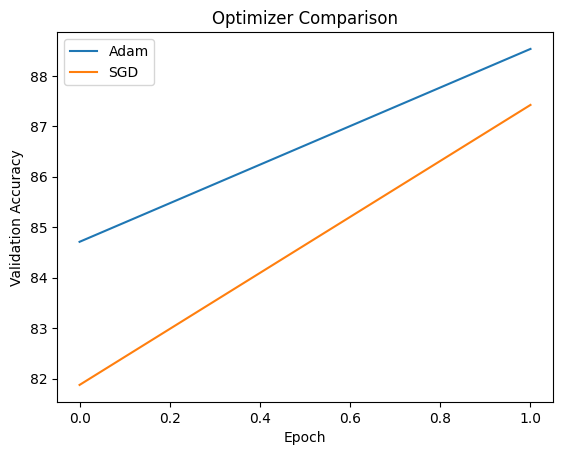

In [60]:
plt.plot(adam_acc, label="Adam")
plt.plot(sgd_acc, label="SGD")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.title("Optimizer Comparison")
plt.show()

In [62]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for model_name, model_instance in [("Adam", adam_model), ("SGD", sgd_model)]:
    print(f"\n--- Test Results for {model_name} ---")
    model_instance.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model_instance(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds))
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))
    print("Test Accuracy:", accuracy_score(all_labels, all_preds))


--- Test Results for Adam ---
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       660
           1       0.89      0.47      0.62       152

    accuracy                           0.89       812
   macro avg       0.89      0.73      0.78       812
weighted avg       0.89      0.89      0.88       812

Confusion Matrix:
 [[651   9]
 [ 80  72]]
Test Accuracy: 0.8903940886699507

--- Test Results for SGD ---
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       660
           1       0.79      0.49      0.61       152

    accuracy                           0.88       812
   macro avg       0.84      0.73      0.77       812
weighted avg       0.87      0.88      0.87       812

Confusion Matrix:
 [[640  20]
 [ 77  75]]
Test Accuracy: 0.8805418719211823


In [63]:
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

adam_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = adam_model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i].to(device):
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].item())
                misclassified_preds.append(preds[i].item())

print("Total Misclassified:", len(misclassified_images))

Total Misclassified: 89


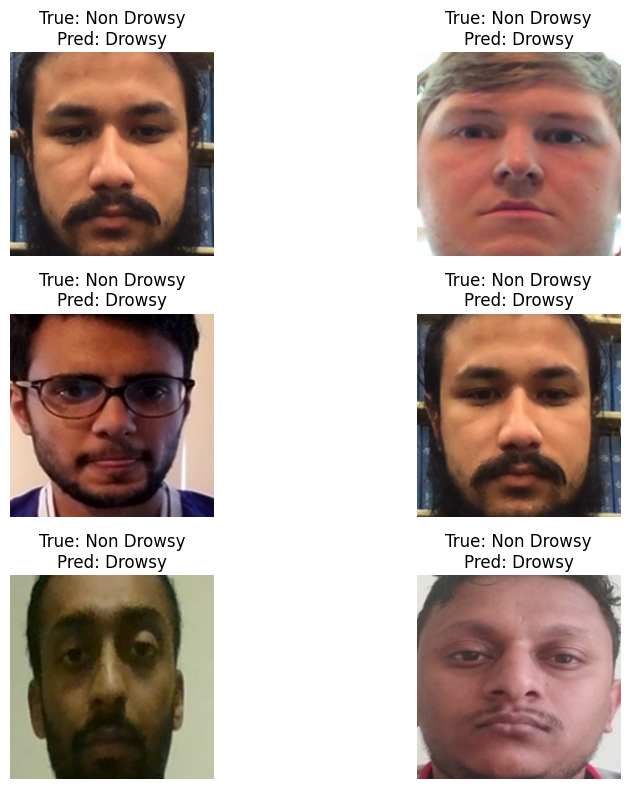

In [64]:
import random

class_names = full_dataset.classes

num_samples = 6
indices = random.sample(range(len(misclassified_images)), num_samples)

plt.figure(figsize=(10,8))

for i, idx in enumerate(indices):
    img = misclassified_images[idx]
    label = misclassified_labels[idx]
    pred = misclassified_preds[idx]

    # unnormalize
    img = img * 0.5 + 0.5
    img = img.permute(1,2,0)

    plt.subplot(3,2,i+1)
    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
import time

def measure_inference_time(model, loader, use_half=False):
    model.eval()

    if use_half:
        model = model.half()

    start_time = time.time()

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)

            if use_half:
                images = images.half()

            outputs = model(images)

    end_time = time.time()

    return end_time - start_time


# زمان حالت عادی (FP32)
time_fp32 = measure_inference_time(adam_model, test_loader, use_half=False)

print("⏱️ Inference Time (FP32):", time_fp32)

⏱️ Inference Time (FP32): 6.424776315689087


In [74]:
adam_model_fp16 = ViT().to(device)
adam_model_fp16.load_state_dict(torch.load("/content/drive/MyDrive/vit_drowsiness_adam.pth"))


time_fp16 = measure_inference_time(adam_model_fp16, test_loader, use_half=True)

print("⏱️ Inference Time (FP16):", time_fp16)

# درصد بهبود سرعت
speedup = (time_fp32 - time_fp16) / time_fp32 * 100
print(f"🚀 Speed Improvement: {speedup:.2f}%")

⏱️ Inference Time (FP16): 5.8488335609436035
🚀 Speed Improvement: 8.96%


In [75]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, loader, use_half=False):
    model.eval()
    all_preds = []
    all_labels = []

    if use_half:
        model = model.half()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            if use_half:
                images = images.half()

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return accuracy_score(all_labels, all_preds)


acc_fp32 = evaluate_model(adam_model, test_loader, use_half=False)

# دوباره لود می‌کنیم برای اینکه مدل دست‌کاری نشده باشه
adam_model_fp16 = ViT().to(device)
adam_model_fp16.load_state_dict(torch.load("/content/drive/MyDrive/vit_drowsiness_adam.pth"))

acc_fp16 = evaluate_model(adam_model_fp16, test_loader, use_half=True)

print("Accuracy FP32:", acc_fp32)
print("Accuracy FP16:", acc_fp16)

Accuracy FP32: 0.8903940886699507
Accuracy FP16: 0.8903940886699507


In [76]:
class TemporalWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, sequence_length=3):
        self.dataset = dataset
        self.seq_len = sequence_length

    def __len__(self):
        return len(self.dataset) - self.seq_len

    def __getitem__(self, idx):
        images = []
        labels = []

        for i in range(self.seq_len):
            img, label = self.dataset[idx + i]
            images.append(img)
            labels.append(label)

        # فرض می‌کنیم لیبل آخر مهمه
        return torch.stack(images), labels[-1]


temporal_test_dataset = TemporalWrapper(test_dataset, sequence_length=3)
temporal_test_loader = DataLoader(temporal_test_dataset, batch_size=32)

print("Temporal test size:", len(temporal_test_dataset))

Temporal test size: 809


In [77]:
class TemporalViT(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.feature_extractor = base_model

        self.temporal_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=2,  # چون خروجی ما 2 کلاسه
                nhead=1,
                batch_first=True
            ),
            num_layers=1
        )

    def forward(self, x):
        B, T, C, H, W = x.shape

        outputs = []
        for t in range(T):
            out = self.feature_extractor(x[:, t])
            outputs.append(out)

        outputs = torch.stack(outputs, dim=1)  # (B,T,2)

        temporal_out = self.temporal_transformer(outputs)
        final_out = temporal_out[:, -1, :]  # آخرین زمان

        return final_out


# ساخت مدل
temporal_model = TemporalViT(adam_model).to(device)

/tmp/ipython-input-2874074636.py:6: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.temporal_transformer = nn.TransformerEncoder(


In [78]:
from sklearn.metrics import accuracy_score

temporal_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in temporal_test_loader:
        images = images.to(device)
        outputs = temporal_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

temporal_acc = accuracy_score(all_labels, all_preds)

print("📊 Baseline Adam Accuracy:", acc_fp32)
print("📊 Temporal Model Accuracy:", temporal_acc)

📊 Baseline Adam Accuracy: 0.8903940886699507
📊 Temporal Model Accuracy: 0.899876390605686


In [79]:
from copy import deepcopy

num_clients = 3
client_data_size = len(train_dataset) // num_clients

client_loaders = []

for i in range(num_clients):
    start = i * client_data_size
    end = (i+1) * client_data_size
    subset = torch.utils.data.Subset(train_dataset, range(start, end))
    loader = DataLoader(subset, batch_size=32, shuffle=True)
    client_loaders.append(loader)

print("Clients created:", len(client_loaders))

Clients created: 3


In [80]:
def train_one_client(model, loader):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    return model.state_dict()

In [81]:
def federated_average(weights_list):
    avg_weights = deepcopy(weights_list[0])

    for key in avg_weights.keys():
        for i in range(1, len(weights_list)):
            avg_weights[key] += weights_list[i][key]
        avg_weights[key] = avg_weights[key] / len(weights_list)

    return avg_weights

In [82]:
global_model = ViT().to(device)
global_model.load_state_dict(torch.load("/content/drive/MyDrive/vit_drowsiness_adam.pth"))

client_weights = []

for client_loader in client_loaders:
    local_model = ViT().to(device)
    local_model.load_state_dict(global_model.state_dict())

    weights = train_one_client(local_model, client_loader)
    client_weights.append(weights)

# تجمیع
new_global_weights = federated_average(client_weights)
global_model.load_state_dict(new_global_weights)

print("Federated aggregation done.")

Federated aggregation done.


In [83]:
federated_acc = evaluate_model(global_model, test_loader)

print("Baseline Adam Accuracy:", acc_fp32)
print("Federated Model Accuracy:", federated_acc)

Baseline Adam Accuracy: 0.8903940886699507
Federated Model Accuracy: 0.9298029556650246
